In [2]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd

run_number = 51

branch_list = [
    'Detector', 'Feb', 'Multiplicity', 'Channel',
    'Cell0TimeStamp', 'TimeInstant', 'TOTValue', 'PeakValue',
    'Baseline', 'Amplitude', 'ArraySize',
    'xCoord', 'yCoord', 'Davide', 'Golia', '7PAD', 'MCP',
]

branch_2d = [
    'Detector', 'Feb', 'Multiplicity', 'Channel',
    'Cell0TimeStamp', 'TimeInstant', 'TOTValue', 'PeakValue',
    'Baseline', 'Amplitude', 'xCoord', 'yCoord'
]

branch_1d = ['ArraySize', 'Davide', 'Golia', '7PAD', 'MCP']

chunks = []

with uproot.open(f"~/Scrivania/sampic_run{run_number}_merged.root") as file:
    tree = file["picoTree"]
    n_tot = tree.num_entries

    for i, chunk in enumerate(tree.iterate(branch_list, library="ak", step_size=50_000)):
        n_chunk = len(chunk)

        # ArraySize dice esattamente quante hit valide ci sono per evento
        array_size = ak.to_numpy(chunk['ArraySize'])  # shape (n_chunk,)

        # --- Branch 2D: taglia ogni riga a ArraySize invece di usare maschera -1 ---
        arr_2d = {k: ak.to_numpy(chunk[k]) for k in branch_2d}

        rows_2d = {k: [] for k in branch_2d}
        for evt in range(n_chunk):
            n_hit = array_size[evt]
            for k in branch_2d:
                rows_2d[k].append(arr_2d[k][evt, :n_hit])

        df_2d = pd.DataFrame({k: np.concatenate(rows_2d[k]) for k in branch_2d})

        # --- Branch 1D: ripeti per ogni hit dell'evento ---
        arr_1d = {k: ak.to_numpy(chunk[k]) for k in branch_1d}
        df_1d = pd.DataFrame({k: np.repeat(arr_1d[k], array_size) for k in branch_1d})


         # --- Waveform ---
        #waveform_raw = ak.to_numpy(chunk['Waveform'])
        #waveforms = []
        #for evt in range(n_chunk):
        #    n_hit = array_size[evt]
        #    for hit in range(n_hit):
        #        waveforms.append(waveform_raw[evt, hit, :])
        #df_2d['Waveform'] = waveforms
        





        # --- Multiplicity: estrai le 3 posizioni come colonne separate ---
        mult = ak.to_numpy(chunk['Multiplicity'])  # shape (n_chunk, 140)
        df_mult_per_evento = pd.DataFrame({
            'Mult_det0': mult[:, 0],
            'Mult_det1': mult[:, 1],
            'Mult_det2': mult[:, 2],
        })
        # Ripeti per ogni hit dell'evento
        df_mult = pd.DataFrame({
            col: np.repeat(df_mult_per_evento[col].values, array_size)
            for col in df_mult_per_evento.columns
        })

        # --- Indice evento ---
        event_idx = np.repeat(np.arange(i * 50_000, i * 50_000 + n_chunk), array_size)

        # --- Assembla ---
        df_chunk = pd.concat([
            pd.Series(event_idx, name='event_idx'),
            df_2d.reset_index(drop=True),
            df_1d.reset_index(drop=True),
            df_mult.reset_index(drop=True)
        ], axis=1)

        # Rimuovi Multiplicity grezza (era 2D, ora abbiamo le 3 colonne separate)
        df_chunk.drop(columns=['Multiplicity'], inplace=True)

        chunks.append(df_chunk)
        print(f"Chunk {i+1} — eventi: {n_chunk} — hit totali: {len(df_chunk)} — letti: {min((i+1)*50_000, n_tot)}/{n_tot}")

df = pd.concat(chunks, ignore_index=True)
print(f"\n✅ DataFrame finale: {df.shape}")
print(df.head(50))

Chunk 1 — eventi: 50000 — hit totali: 93499 — letti: 50000/638043
Chunk 2 — eventi: 50000 — hit totali: 72236 — letti: 100000/638043
Chunk 3 — eventi: 50000 — hit totali: 68193 — letti: 150000/638043
Chunk 4 — eventi: 50000 — hit totali: 75496 — letti: 200000/638043
Chunk 5 — eventi: 50000 — hit totali: 75299 — letti: 250000/638043
Chunk 6 — eventi: 50000 — hit totali: 66798 — letti: 300000/638043
Chunk 7 — eventi: 50000 — hit totali: 74427 — letti: 350000/638043
Chunk 8 — eventi: 50000 — hit totali: 67345 — letti: 400000/638043
Chunk 9 — eventi: 50000 — hit totali: 74660 — letti: 450000/638043
Chunk 10 — eventi: 50000 — hit totali: 74350 — letti: 500000/638043
Chunk 11 — eventi: 50000 — hit totali: 67146 — letti: 550000/638043
Chunk 12 — eventi: 50000 — hit totali: 67966 — letti: 600000/638043
Chunk 13 — eventi: 38043 — hit totali: 54899 — letti: 638043/638043

✅ DataFrame finale: (932314, 20)
    event_idx  Detector  Feb  Channel  Cell0TimeStamp   TimeInstant  TOTValue  \
0          

In [3]:
#opèerating directly on pandas DataFrame

#at least 1 hit on detector 1
det1 = (df['Mult_det1'] == 1) & (df['event_idx'] > 100000) # primi 50000 eventi det 1 ha trippato
#noisy = (df['Detector']==2 & (df['xCoord']!=9 | df['yCoord']!=5)) #det 2 ha un canale rumoroso (9,5) che trippa sempre, escludiamolo
print(f"Eventi con  1 hit su det1: {det1.sum()}")


df_det1 = df[det1]
#df_det1 = df_det1[noisy]
print(f"DataFrame filtrato (det1==1): {df_det1.shape}")
print(df_det1.head(50))

#plot di multiplicity per det

Eventi con  1 hit su det1: 523470
DataFrame filtrato (det1==1): (523470, 20)
        event_idx  Detector  Feb  Channel  Cell0TimeStamp   TimeInstant  \
165736     100001       2.0    1       32    1.497343e+11  1.497343e+11   
165737     100002       2.0    1       51    1.497343e+11  1.497343e+11   
165738     100003       2.0    1       32    1.497347e+11  1.497347e+11   
165739     100004       2.0    1       32    1.497353e+11  1.497353e+11   
165741     100006       2.0    1       32    1.497372e+11  1.497372e+11   
165743     100008       2.0    1       32    1.497431e+11  1.497431e+11   
165744     100009       2.0    1       32    1.497432e+11  1.497432e+11   
165746     100011       2.0    1       32    1.497433e+11  1.497433e+11   
165747     100012       2.0    1       32    1.497435e+11  1.497435e+11   
165748     100013       2.0    1       32    1.497436e+11  1.497436e+11   
165749     100014       2.0    1       32    1.497438e+11  1.497438e+11   
165750     100015      

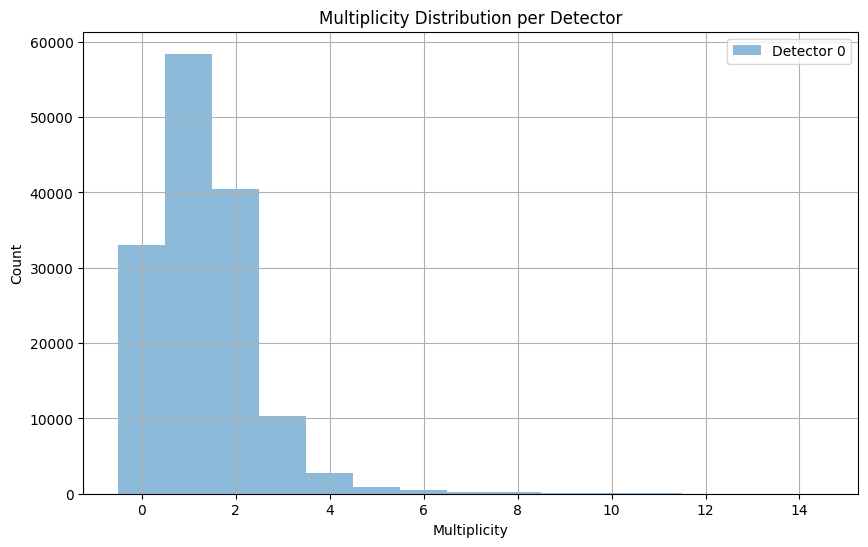

In [4]:
import matplotlib.pyplot as plt
#higher thshold for ampitude to exclude noise
df_det1 = df_det1[df_det1['Amplitude'] < -0.02] #escludiamo rumore con ampiezza < 0.02
plt.figure(figsize=(10, 6)) 
plt.hist(df_det1['Mult_det0'], bins=np.arange(-0.5, df_det1['Mult_det0'].max()+1.5, 1), alpha=0.5, label='Detector 0')
plt.xlabel('Multiplicity')
plt.ylabel('Count')
plt.title('Multiplicity Distribution per Detector')
plt.legend()
plt.grid()
plt.show()  

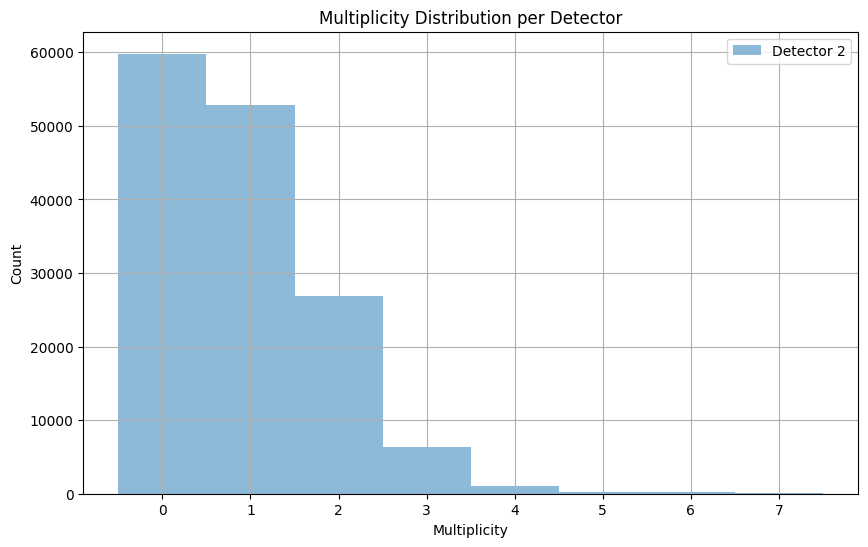

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6)) 

plt.hist(df_det1['Mult_det2'], bins=np.arange(-0.5, df_det1['Mult_det2'].max()+1.5, 1), alpha=0.5, label='Detector 2')
plt.xlabel('Multiplicity')
plt.ylabel('Count')
plt.title('Multiplicity Distribution per Detector')
plt.legend()
plt.grid()
plt.show()  

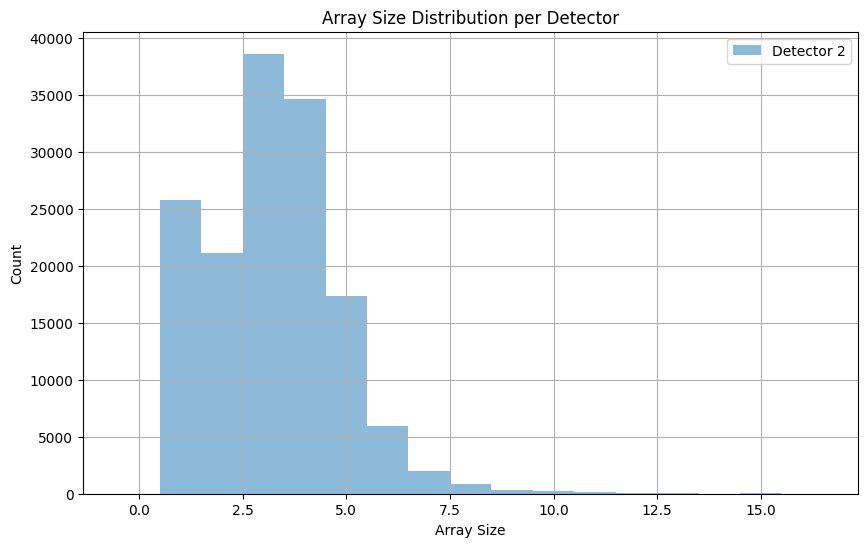

In [6]:
plt.figure(figsize=(10, 6)) 

plt.hist(df_det1['ArraySize'], bins=np.arange(-0.5, df_det1['ArraySize'].max()+1.5, 1), alpha=0.5, label='Detector 2')
plt.xlabel('Array Size')
plt.ylabel('Count')
plt.title('Array Size Distribution per Detector')
plt.legend()
plt.grid()
plt.show()  

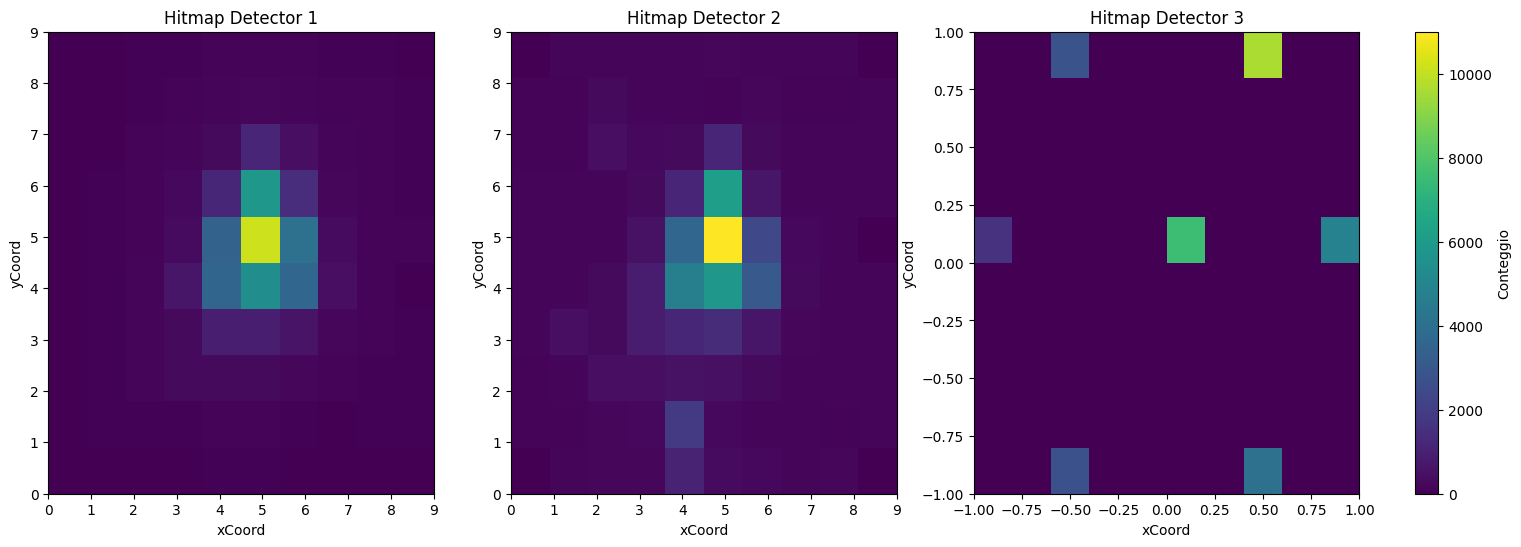

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

new_df = df_det1[df_det1['ArraySize'] >= 1]

bins = 10
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Primo passaggio: calcola tutti gli istogrammi e trova il max globale ---
histograms = []
for det_id in [1, 2, 3]:
    df_1 = new_df[new_df['Detector'] == det_id].copy()
    if det_id == 2:
        df_1 = df_1[(df_1["xCoord"] != 9) | (df_1["yCoord"] != 5)]
    
    h, xedges, yedges = np.histogram2d(df_1['xCoord'], df_1['yCoord'], bins=bins)
    histograms.append((h, xedges, yedges))

# Scala comune basata sul massimo reale dei dati
vmin = 0
vmax = max(h.max() for h, _, _ in histograms)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = 'viridis'

# --- Secondo passaggio: disegna con scala identica ---
for i, (det_id, (h, xedges, yedges)) in enumerate(zip([1, 2, 3], histograms)):
    ax = axes[i]
    mesh = ax.pcolormesh(xedges, yedges, h.T, cmap=cmap, norm=norm)
    ax.set_title(f'Hitmap Detector {det_id}')
    ax.set_xlabel('xCoord')
    ax.set_ylabel('yCoord')

# Colorbar unica condivisa
fig.colorbar(mesh, ax=axes, orientation='vertical', fraction=0.02, pad=0.04, label='Conteggio')

#plt.tight_layout()
plt.show()

In [ ]:
# 1 hit su detector 2
#riempio tutto il resto >=1
# efficienza di davide facendo rapporto canale per canale 

#efficienza guardando i canali accoppiati: per ogni hit nel canale x guardo quante ce ne sono nel canale x dell'altro detector

#run 51 e run normale con intensità normale (run muoni)

: 

: 